# Surrogate model evaluation

Runs the same offline accuracy evaluation as `evaluator.py`'s `evaluate_surrogate()` -- the same
function used by the `evaluate_surrogate` CLI command. Nothing here reimplements the metrics: every
number and every plot below comes from calling `evaluate_surrogate()` itself.

The report covers per-feature and per-stage regression errors, then the final-score metrics -- but
read the callout in section 2 before drawing conclusions from the "all samples" score numbers: the RL
environments in this repo treat `npart_ratio < 0.10` (`RL_MIN_NPART_RATIO`) as an episode-terminating
failure, not a scored transition, so the all-sample score distribution is dominated by the
discontinuous `ERROR_SCORE` cliff and largely uninformative on its own -- the `npart_ratio >= 0.10` row
is the one that reflects what an RL agent actually experiences as reward.

**Works with any surrogate family**: point `MODEL_DIR` (section "Modify here") at any folder holding
`surrogate_<dataset_id>_*.pt` checkpoints -- the dataset id and its matching `dataset_test.pt` are
auto-detected from the checkpoint filenames, following the project's standard naming convention
(`SurrogateDatasetUpdater`/`trainer.py`). No other cell needs editing to switch surrogate families.

This notebook is read-only: it loads existing checkpoints/datasets and evaluates them in memory, it
does not train, fine-tune, or write anything back to `trained_models/`.

**Related notebooks:**
- [`visualize_surrogate_model.ipynb`](visualize_surrogate_model.ipynb) -- the `ModularMLP` architecture
  being evaluated here (layers, input/output contract).
- [`env/dataset/visualize_dataset.ipynb`](../../../dataset/visualize_dataset.ipynb) -- the `BeamDataset`
  format the evaluation dataset below is loaded from.

In [1]:
from pathlib import Path
import sys
import tempfile

import numpy as np
import torch
from IPython.display import Image, Markdown, display

WORKING_DIR = Path.cwd().resolve()
if (WORKING_DIR / 'beam_optimization').is_dir():
    REPO_ROOT = WORKING_DIR
else:
    PROJECT_ROOT = WORKING_DIR
    while PROJECT_ROOT.name != 'beam_optimization' and PROJECT_ROOT.parent != PROJECT_ROOT:
        PROJECT_ROOT = PROJECT_ROOT.parent
    REPO_ROOT = PROJECT_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from beam_optimization.config.adige import RL_MIN_NPART_RATIO
from beam_optimization.config.paths import DEFAULT_BASE_SURROGATE_DIR, DEFAULT_UPDATED_SURROGATE_DIR
from beam_optimization.env.dataset import BeamDataset
from beam_optimization.env.surrogate_env.surrogate.model.modular_mlp import ModularMLP
from beam_optimization.env.surrogate_env.surrogate.model.trainer import compute_normalization_metadata
from beam_optimization.env.surrogate_env.surrogate.model.evaluator import (
    evaluate_surrogate, _default_test_dataset_path, _MeanEnsemble, _checkpoint_provenance,
)


def fmt(value):
    if value is None:
        return 'n/a'
    return f'{float(value):.6g}'


def table(headers, rows):
    lines = ['| ' + ' | '.join(headers) + ' |', '| ' + ' | '.join(['---'] * len(headers)) + ' |']
    lines.extend('| ' + ' | '.join(str(cell) for cell in row) + ' |' for row in rows)
    return '\n'.join(lines)

## Modify here

Point `MODEL_DIR` at any folder holding `surrogate_<dataset_id>_*.pt` checkpoints -- e.g. any
`trained_models/base*` or `trained_models/updated` family, whatever dataset it was trained on.
Everything else below (dataset id, held-out test split, mismatch checks) is derived automatically from
the checkpoint filenames themselves, so this is the only cell you normally need to touch to evaluate a
different surrogate.

In [2]:
# <-- MODIFY HERE: point at any folder containing surrogate_<dataset_id>_*.pt checkpoints.
MODEL_DIR = DEFAULT_BASE_SURROGATE_DIR.parent / 'base_042_softplus_clean'  # the new (softplus) baseline
# e.g. MODEL_DIR = Path('beam_optimization/env/surrogate_env/surrogate/trained_models/updated')
# e.g. MODEL_DIR = DEFAULT_BASE_SURROGATE_DIR / 'surrogate_031_clamp_old'  # the old (clamp) baseline

MODEL_PATTERN = 'surrogate_*.pt'  # narrow to e.g. 'surrogate_031_*.pt' only if MODEL_DIR mixes datasets
DATASET_PATH_OVERRIDE = None  # None = auto-detect env/dataset/<id>/dataset_test.pt from the checkpoints
BUILD_ENSEMBLE_MEAN = True  # effective only when the selected family has multiple members

## 1. Checkpoints and evaluation dataset

Every checkpoint matching `MODEL_PATTERN` in `MODEL_DIR` is evaluated. The dataset id is parsed from
the checkpoint filenames themselves (`surrogate_<id>_<index>.pt`) and used to locate
`env/dataset/<id>/dataset_test.pt`, unless `DATASET_PATH_OVERRIDE` is set explicitly -- in which case
its parent folder name must match the detected id, or execution stops with a clear error. A mean
ensemble is built only from members of that same selected family.

In [3]:
checkpoint_paths = sorted(MODEL_DIR.glob(MODEL_PATTERN)) if MODEL_DIR.exists() else []
checkpoint_source = str(MODEL_DIR) if checkpoint_paths else None

checkpoint_dataset_ids = {path.stem[len('surrogate_'):].rsplit('_', 1)[0] for path in checkpoint_paths}
if len(checkpoint_dataset_ids) > 1:
    raise ValueError(
        f'{MODEL_DIR} mixes checkpoints from different datasets: {sorted(checkpoint_dataset_ids)}. '
        'Narrow MODEL_PATTERN to one dataset id, e.g. "surrogate_031_*.pt".'
    )
detected_dataset_id = next(iter(checkpoint_dataset_ids), None)

if DATASET_PATH_OVERRIDE is not None:
    DATASET_PATH = Path(DATASET_PATH_OVERRIDE)
    if detected_dataset_id is not None and DATASET_PATH.parent.name != detected_dataset_id:
        raise ValueError(
            f'Checkpoint/dataset mismatch: models={sorted(checkpoint_dataset_ids)}, '
            f'dataset={DATASET_PATH.parent.name}. Choose one matching surrogate family and held-out split.'
        )
elif detected_dataset_id is not None:
    DATASET_PATH = REPO_ROOT / f'beam_optimization/env/dataset/{detected_dataset_id}/dataset_test.pt'
else:
    raise ValueError(
        f'No checkpoints found in {MODEL_DIR} and DATASET_PATH_OVERRIDE is None -- set '
        'DATASET_PATH_OVERRIDE explicitly to evaluate an untrained demo model on a chosen dataset.'
    )
if not DATASET_PATH.exists():
    raise FileNotFoundError(f'Evaluation dataset not found: {DATASET_PATH}')
dataset_id = DATASET_PATH.parent.name
dataset = BeamDataset.load(DATASET_PATH)

print(f'{MODEL_DIR}: {len(checkpoint_paths)} checkpoint(s)')
print(f'evaluating {len(checkpoint_paths)} checkpoint(s) from: {checkpoint_source}')
print(f'dataset id: {dataset_id} (auto-detected: {DATASET_PATH_OVERRIDE is None})')

models = []  # list of (name, model, checkpoint_path)
if checkpoint_paths:
    for path in checkpoint_paths:
        models.append((path.name, ModularMLP.load(str(path)), path))
else:
    norm_stats = compute_normalization_metadata(dataset)
    models.append(('untrained (demo)', ModularMLP(norm_stats=norm_stats), None))
    print(f'\nNo trained checkpoint found in {MODEL_DIR} yet (train one with the `train_surrogate` '
          f'command, or point MODEL_DIR above at a directory that already has one). Evaluating a '
          f'freshly-initialized ModularMLP instead so the rest of this notebook still runs end to '
          f'end -- every metric and plot below will reflect random weights, not real surrogate '
          f'accuracy, until a real checkpoint exists.')

print('\nProvenance:')
print(f'  test dataset: {DATASET_PATH.resolve()}')
for name, _, path in models:
    if path is not None:
        provenance = _checkpoint_provenance(path)
        print(f"  {name}: modified={provenance['modified_utc']}, "
              f"train={provenance['train_dataset_path']}, val={provenance['val_dataset_path']}")

[BeamDataset] 16,431 samples loaded from /mnt/meneghetti/FEDERICO_TESI/rl_beam_optimization/beam_optimization/env/dataset/042/dataset_test.pt
/mnt/meneghetti/FEDERICO_TESI/rl_beam_optimization/beam_optimization/env/surrogate_env/surrogate/trained_models/base_042_softplus_clean: 1 checkpoint(s)
evaluating 1 checkpoint(s) from: /mnt/meneghetti/FEDERICO_TESI/rl_beam_optimization/beam_optimization/env/surrogate_env/surrogate/trained_models/base_042_softplus_clean
dataset id: 042 (auto-detected: True)

Provenance:
  test dataset: /mnt/meneghetti/FEDERICO_TESI/rl_beam_optimization/beam_optimization/env/dataset/042/dataset_test.pt
  surrogate_042_0.pt: modified=2026-09-08T09:25:44.277197+00:00, train=beam_optimization/env/dataset/042/dataset_train.pt, val=beam_optimization/env/dataset/042/dataset_val.pt


## 2. Running `evaluate_surrogate()`

Calls the real function once per model, exactly as `evaluate_surrogate_folder()` does internally:
batched forward passes over the whole dataset, per-(stage, feature) SSE/SAE accumulated in native
physical units, then reduced to MSE/MAE/RMSE per stage, per feature, and overall, plus final-score
metrics (MAE, RMSE, bias, Pearson r, R²) via the project's real `score_tensor()`. `plots_dir` points at
a throwaway temporary directory -- the same plotting code `evaluator.py` uses to save PNGs to disk is
reused untouched, the files are just displayed inline here and discarded afterward instead of being
kept under `results/`.

`filter_score_plots_to_rl_valid=True` is passed explicitly: the two score plots (`score_scatter`,
`score_residuals`) are drawn only from samples with true `npart_ratio >= RL_MIN_NPART_RATIO = 0.10`, and
use `score_metrics_rl_valid` instead of `score_metrics`. Their metric boxes are hidden in this
notebook because the same values are already reported in the tables below. No returned metric changes -- this
only restricts which points the two score plots are drawn from. The two RMSE/NRMSE heatmaps are
unaffected (they aggregate errors over all stages/features across every sample, not just the final
stage's npart_ratio, so there is no equally simple way to filter them to the same regime).

> **Reading the score metrics below**: `score_metrics` ("all samples") mixes RL-valid transitions with
> the `npart_ratio <= 0` all-particles-lost cliff (`ERROR_SCORE`, a large fixed penalty) and everything
> in between down to `npart_ratio < RL_MIN_NPART_RATIO = 0.10` -- the range the RL environments treat as
> an episode-terminating failure rather than a real scored step (`TERMINAL_FAILURE_REWARD`, not
> `score()`, per `base_beam_env.py` / `differentiable_surrogate_env.py`). That cliff dominates the
> variance of the "all samples" numbers and makes genuine regression quality in the operating region
> hard to see. `score_metrics_rl_valid` (`npart_ratio >= 0.10`) is the metric that actually corresponds
> to what an RL agent experiences as `score()`-based reward -- read that row, not the all-samples one,
> when judging whether this surrogate is good enough to train a policy on. The plots below are already
> restricted to that same regime.

In [4]:
all_results = {}
with tempfile.TemporaryDirectory() as tmp:
    tmp_dir = Path(tmp)
    for name, model, checkpoint_path in models:
        all_results[name] = evaluate_surrogate(
            model, dataset, plots_dir=tmp_dir, plot_prefix=Path(name).stem,
            filter_score_plots_to_rl_valid=True, annotate_score_plots=False,
        )
        if checkpoint_path is not None:
            all_results[name]['checkpoint_provenance'] = _checkpoint_provenance(checkpoint_path)
        # Plot PNGs must be read into memory now, inside the `with` block, before the
        # temporary directory (and the files in it) are deleted on exit.
        for plot_name, plot_path in all_results[name]['plots'].items():
            all_results[name]['plots'][plot_name] = Path(plot_path).read_bytes()

    if BUILD_ENSEMBLE_MEAN and len(models) > 1 and all(path is not None for _, _, path in models):
        ensemble = _MeanEnsemble([model for _, model, _ in models])
        all_results['ensemble_mean'] = evaluate_surrogate(
            ensemble, dataset, plots_dir=tmp_dir, plot_prefix='ensemble_mean',
            filter_score_plots_to_rl_valid=True, annotate_score_plots=False,
        )
        all_results['ensemble_mean']['ensemble_size'] = len(models)
        for plot_name, plot_path in all_results['ensemble_mean']['plots'].items():
            all_results['ensemble_mean']['plots'][plot_name] = Path(plot_path).read_bytes()

print(f'Evaluated {len(all_results)} report(s) on {len(dataset):,} samples from {DATASET_PATH.name}.')
if len(models) == 1:
    print('Only one checkpoint is available: ensemble uncertainty cannot be evaluated yet.')

Evaluated 1 report(s) on 16,431 samples from dataset_test.pt.
Only one checkpoint is available: ensemble uncertainty cannot be evaluated yet.


## 3. Report, per model

### `surrogate_042_0.pt`

**Summary**

| Metric | Value |
| --- | --- |
| Samples | 16,431 |
| Physical non-failure / all lost | 13,831 / 2,600 |
| RL-valid (>= 0.1) / terminal (< 0.1) | 8,448 / 7,983 |
| RMSE all stages (native units) | 8.60285 |
| NRMSE all stages (dimensionless) | 0.554287 |
| RMSE final stage (native units) | 0.944457 |

**Score metrics split by physical regime**

| Group | N | MAE | MAE 95% CI | RMSE | Bias | Pearson r | R² |
| --- | --- | --- | --- | --- | --- | --- | --- |
| All samples (regressor only) | 16,431 | 161.468 | [155.844, 167.843] | 400.727 | 159.633 | -0.125565 | -0.200596 |
| Physical non-failure (npart > 0) | 13,831 | 2.46202 | [2.40496, 2.51656] | 4.28526 | 0.281644 | 0.961159 | 0.919924 |
| All particles lost (npart = 0) | 2,600 | 1007.32 | [1007.14, 1007.54] | 1007.33 | 1007.32 | n/a | n/a |
| RL-valid (npart >= 0.1) | 8,448 | 1.97673 | [1.93749, 2.01696] | 2.76145 | -0.956645 | 0.976069 | 0.94547 |
| RL-terminal (npart < 0.1) | 7,983 | 330.25 | [320.011, 341.116] | 574.9 | 329.576 | -0.746589 | -0.541978 |

> "All samples" includes the discontinuous ERROR_SCORE cliff and the RL-terminal region (`npart_ratio < 0.1`), which the RL environments never actually score -- they end the episode with a fixed terminal penalty instead. **Read the `npart_ratio >= 0.1` row** for the regression quality that matters to a trained policy; "physical non-failure (npart > 0)" is a different, wider split that still includes the near-zero terminal band.

**RL terminal decision from the regressor alone, at `npart_ratio < 0.1`**

| Precision | Recall | Specificity | F1 | Balanced accuracy | TP / FP / FN / TN |
| --- | --- | --- | --- | --- | --- |
| 0.93252 | 0.976325 | 0.933239 | 0.95392 | 0.954782 | 7794 / 564 / 189 / 7884 |

**Final `npart_ratio` by operational band**

| True band | N | True mean | Predicted mean | MAE | Bias | Regressor terminal rate |
| --- | --- | --- | --- | --- | --- | --- |
| npart_ratio <= 0 | 2,600 | 0 | 0.0136006 | 0.0136006 | 0.0136006 | 0.987308 |
| 0 < npart_ratio < 0.1 | 5,383 | 0.0433514 | 0.0432895 | 0.00952356 | -6.19021e-05 | 0.97102 |
| 0.1 <= npart_ratio < 0.25 | 5,494 | 0.168491 | 0.156509 | 0.0177037 | -0.0119819 | 0.097379 |
| npart_ratio >= 0.25 | 2,954 | 0.337253 | 0.311386 | 0.0282028 | -0.0258661 | 0.0098172 |

> The terminal rate should be high in the first two rows (true failure/near-failure) and low in the RL-valid rows -- this is the raw regressor threshold at 0.10.

**Per-feature errors on all samples**

| Feature | RMSE all | MAE all | RMSE final | NRMSE final | Target std final |
| --- | --- | --- | --- | --- | --- |
| `npart_ratio` | 0.0606443 | 0.0168931 | 0.0285199 | 0.231277 | 0.123315 |
| `x0` | 3.88517 | 0.755607 | 0.904213 | 0.357088 | 2.53219 |
| `y0` | 5.61469 | 0.613111 | 0.732813 | 0.235209 | 3.11559 |
| `SizeX` | 5.24615 | 0.765157 | 0.566848 | 0.319476 | 1.77431 |
| `SizeY` | 5.46041 | 0.584817 | 0.711611 | 0.469355 | 1.51615 |
| `ex` | 2.92781 | 0.180647 | 0.00693458 | 0.385365 | 0.0179948 |
| `ey` | 0.423838 | 0.0315917 | 0.0104279 | 0.429459 | 0.0242814 |
| `x'0` | 22.8815 | 1.74514 | 1.56968 | 0.257207 | 6.10277 |
| `y'0` | 5.4594 | 0.790597 | 1.8387 | 0.284901 | 6.45382 |

**Per-feature errors where predicted final `npart_ratio >= 0.1`** (8,073 samples)

| Feature | RMSE all | MAE all | RMSE final | NRMSE final | Target std final |
| --- | --- | --- | --- | --- | --- |
| `npart_ratio` | 0.023231 | 0.00722042 | 0.0282645 | 0.286654 | 0.0986017 |
| `x0` | 0.888142 | 0.369533 | 0.374239 | 0.192369 | 1.94542 |
| `y0` | 1.30184 | 0.273665 | 0.384132 | 0.137632 | 2.79101 |
| `SizeX` | 1.42746 | 0.316975 | 0.271909 | 0.428916 | 0.633945 |
| `SizeY` | 1.05671 | 0.145197 | 0.257873 | 0.38735 | 0.665735 |
| `ex` | 0.462462 | 0.0381622 | 0.00342296 | 0.273544 | 0.0125134 |
| `ey` | 0.0506723 | 0.00873368 | 0.00431367 | 0.44113 | 0.00977868 |
| `x'0` | 4.89565 | 0.43694 | 0.701952 | 0.113375 | 6.19143 |
| `y'0` | 1.30575 | 0.383261 | 0.817166 | 0.134858 | 6.05947 |

**Per-stage errors** — raw RMSE mixes physical units; NRMSE is the comparable column.

| Stage marker | RMSE native | NRMSE |
| --- | --- | --- |
| 2 | 0.118861 | 0.891172 |
| 29 | 0.0792913 | 0.687152 |
| 108 | 0.116168 | 0.499669 |
| 151 | 0.171942 | 0.528106 |
| 162 | 0.368504 | 0.523214 |
| 195 | 0.411696 | 0.443413 |
| 197 | 29.0838 | 0.74636 |
| 203 | 3.60558 | 0.534126 |
| 205 | 4.77935 | 0.411265 |
| 225 | 1.40461 | 0.364252 |
| 261 | 1.77991 | 0.402378 |
| 332 | 0.944457 | 0.339763 |

**Checkpoint provenance**

| Field | Value |
| --- | --- |
| Path | /mnt/meneghetti/FEDERICO_TESI/rl_beam_optimization/beam_optimization/env/surrogate_env/surrogate/trained_models/base_042_softplus_clean/surrogate_042_0.pt |
| Modified UTC | 2026-09-08T09:25:44.277197+00:00 |
| Training dataset | beam_optimization/env/dataset/042/dataset_train.pt |
| Validation dataset | beam_optimization/env/dataset/042/dataset_val.pt |
| Best validation loss | 0.319423 |

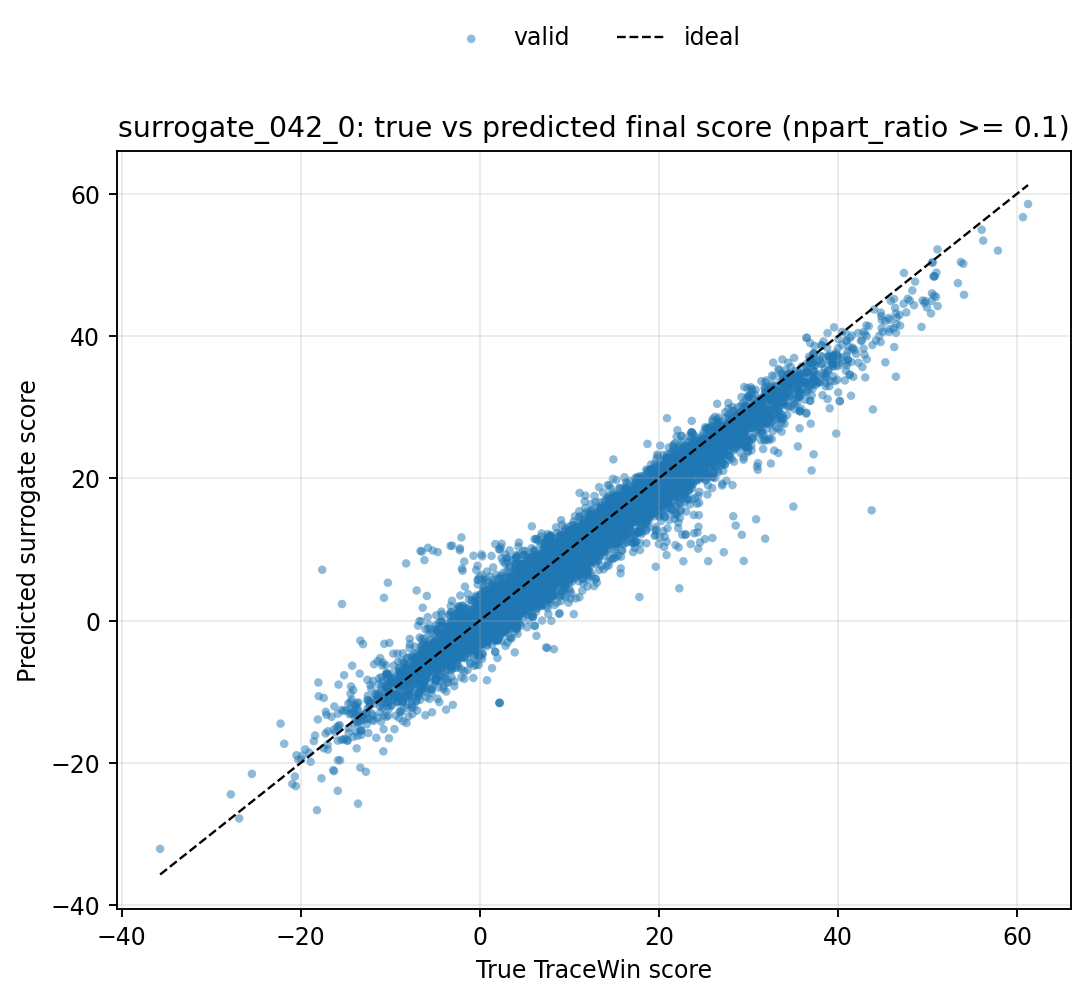

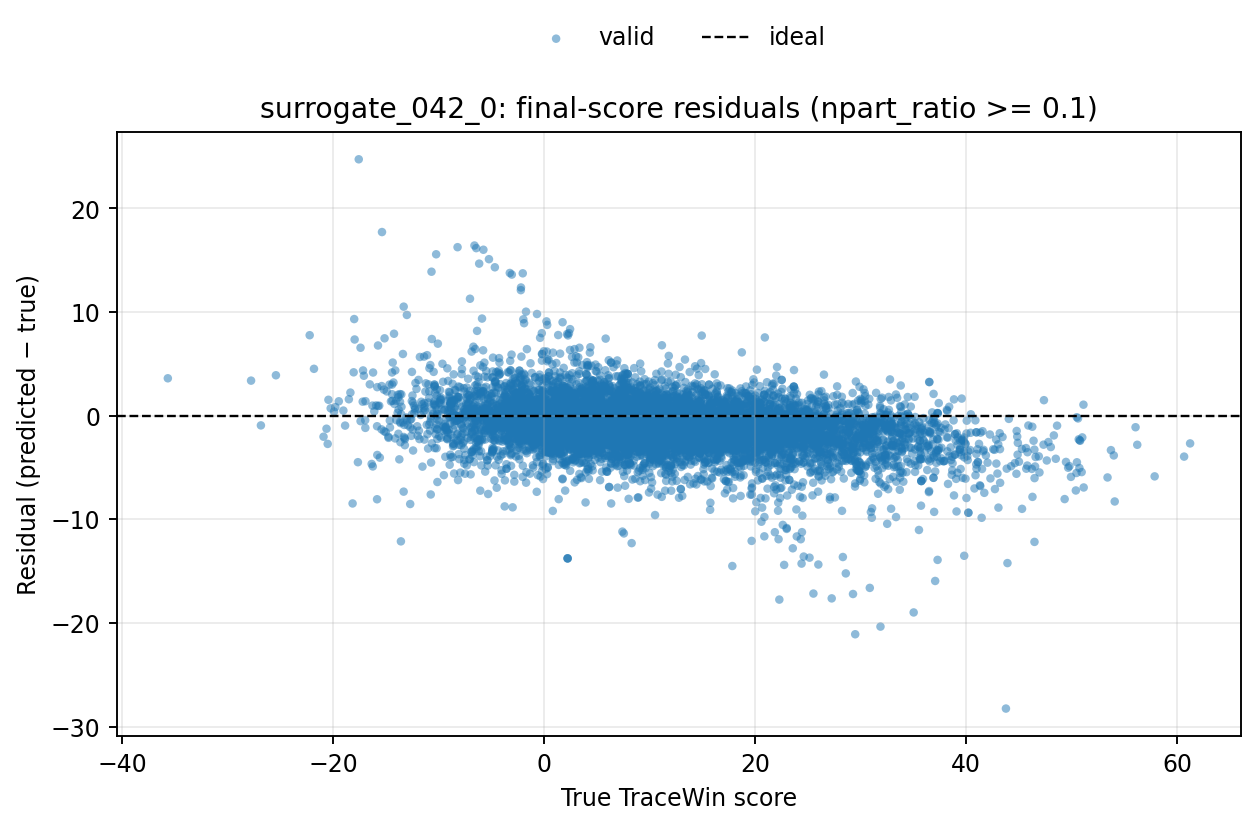

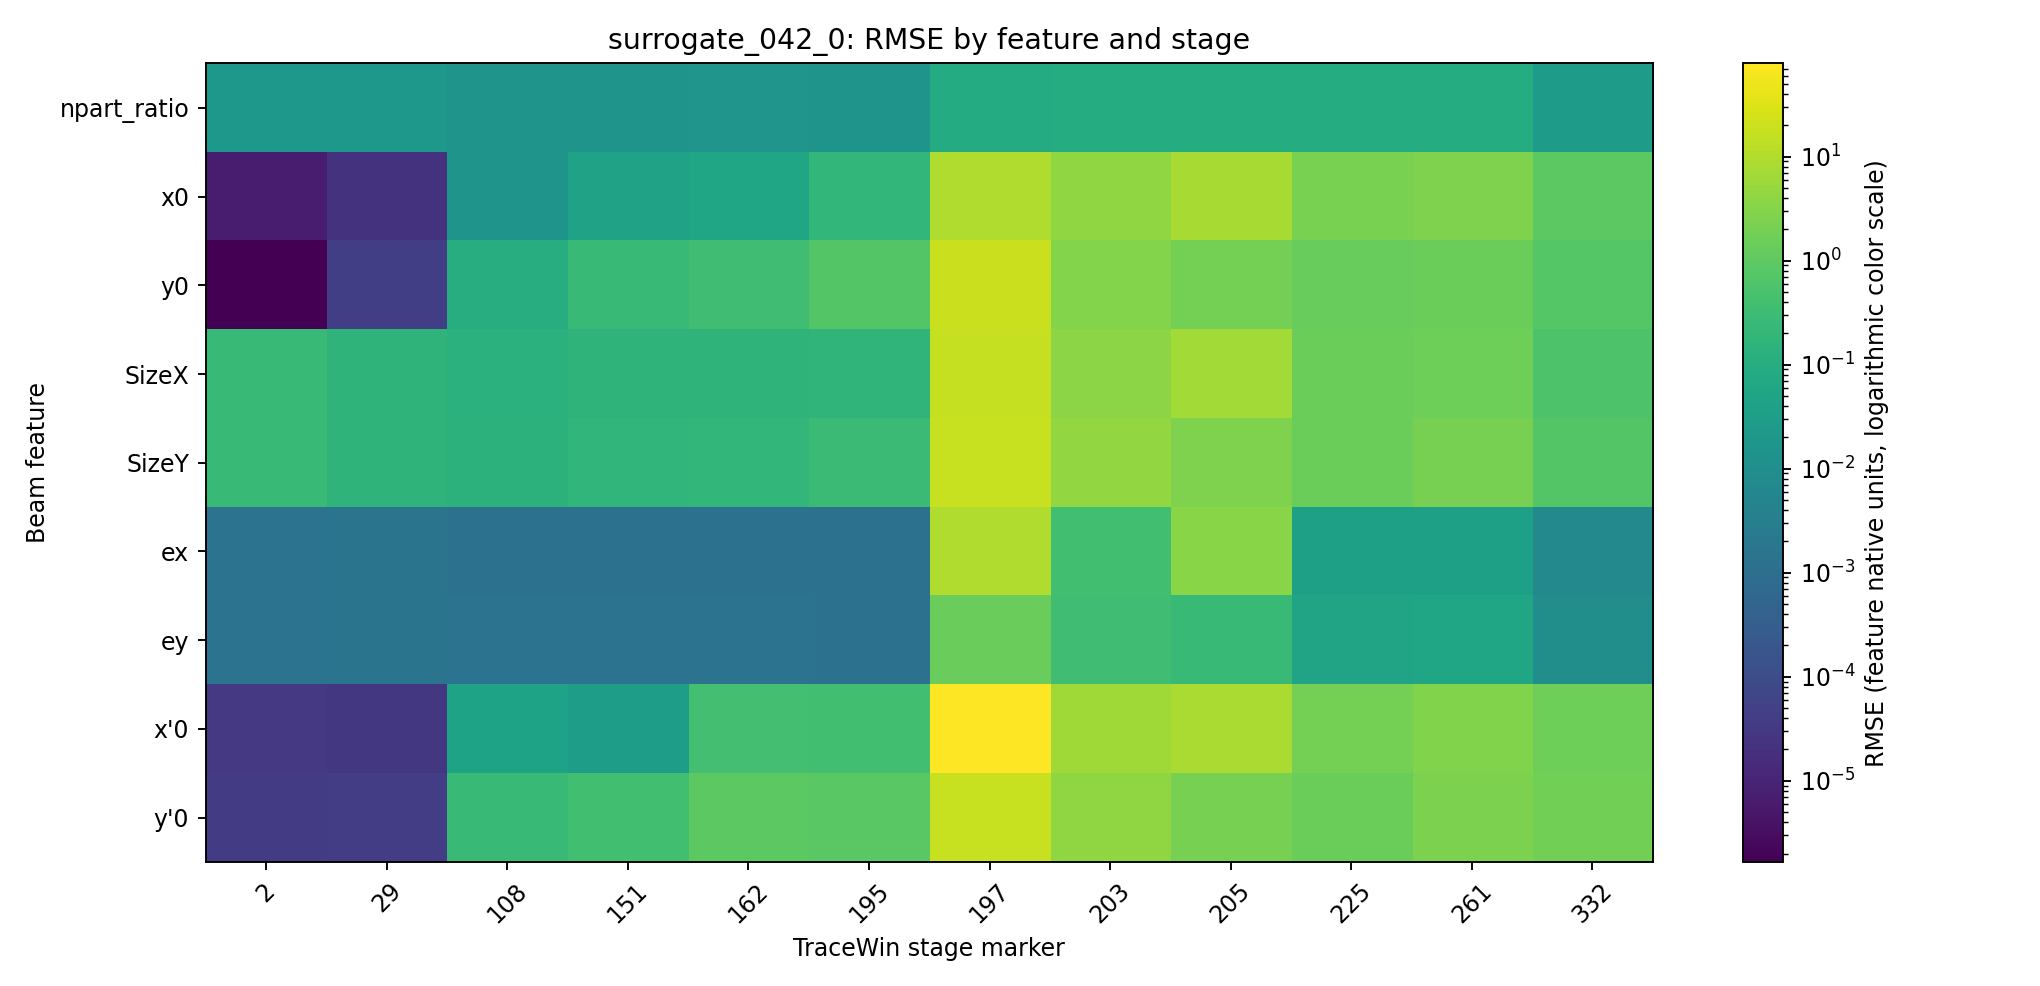

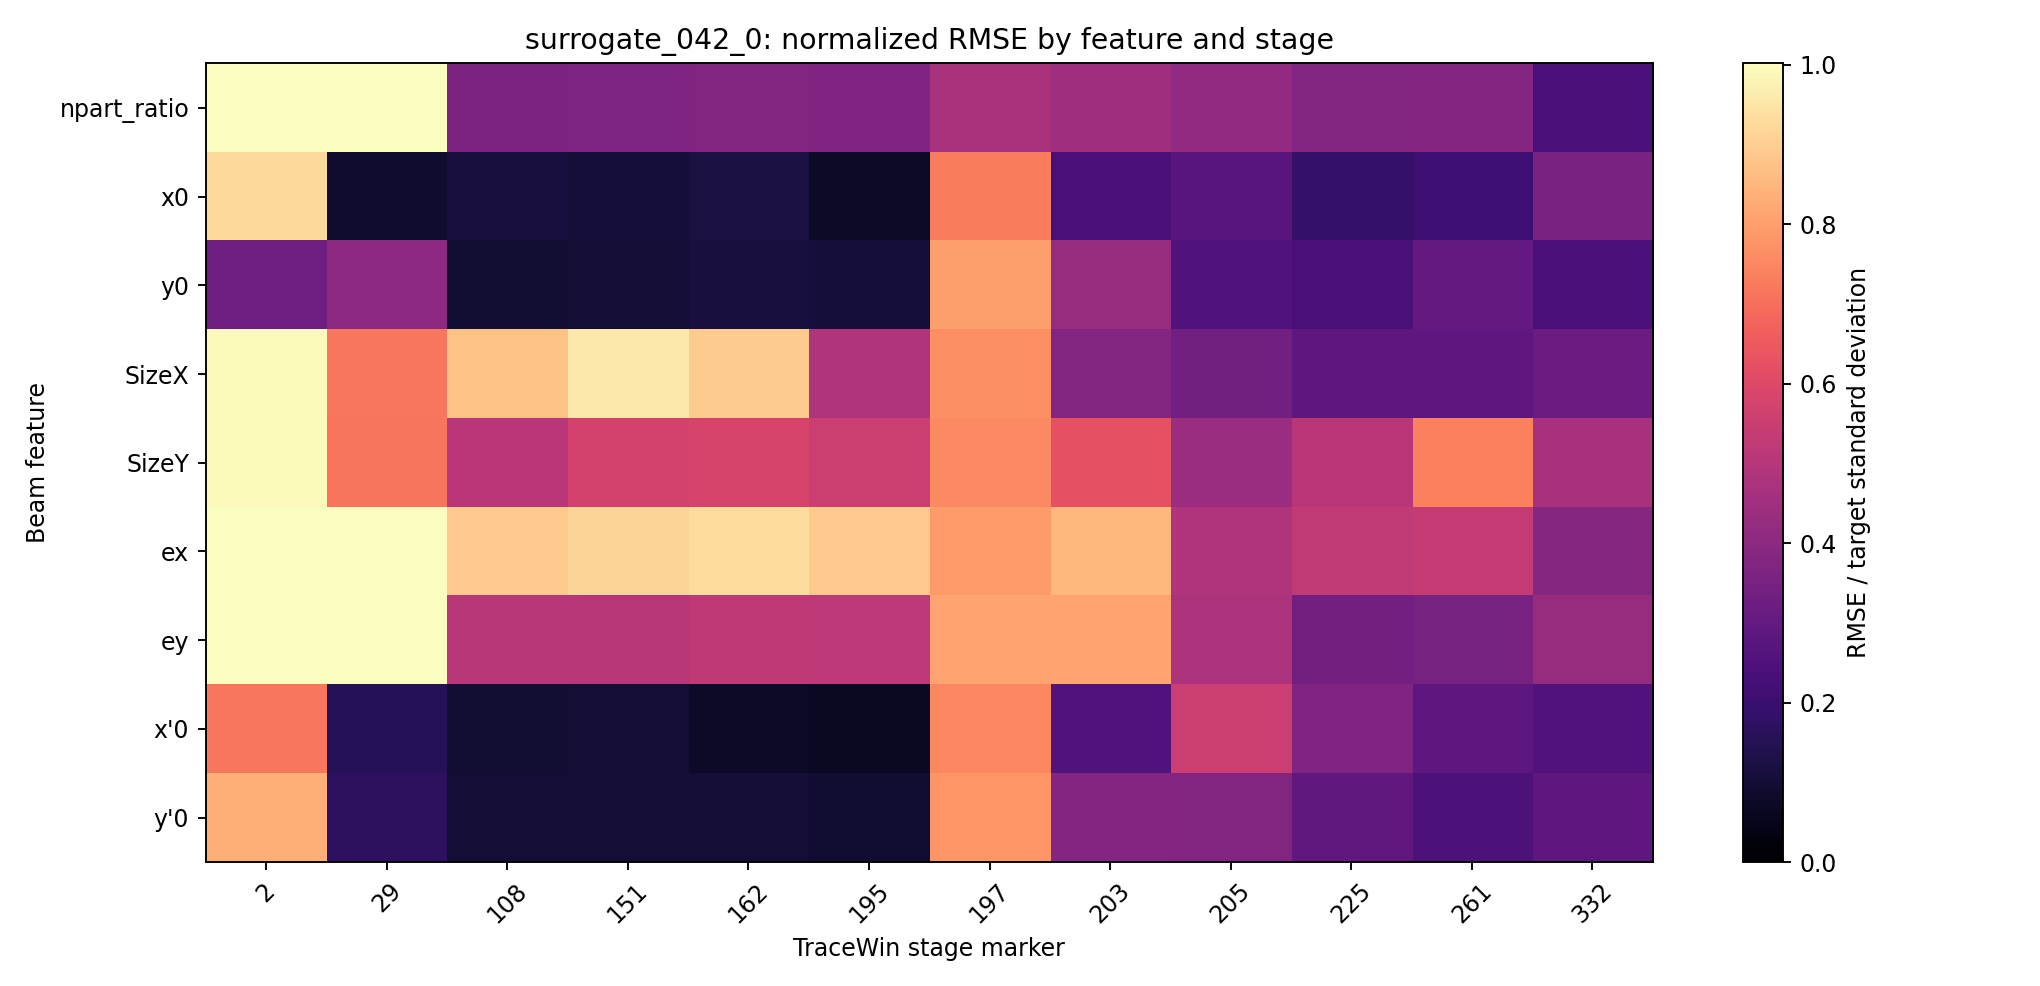

In [5]:
for name, metrics in all_results.items():
    groups = metrics['sample_groups']
    rl_groups = metrics['rl_sample_groups']
    summary_rows = [
        ['Samples', f"{metrics['n_samples']:,}"],
        ['Physical non-failure / all lost', f"{groups['n_valid']:,} / {groups['n_failures']:,}"],
        [f'RL-valid (>= {RL_MIN_NPART_RATIO:g}) / terminal (< {RL_MIN_NPART_RATIO:g})',
         f"{rl_groups['n_valid']:,} / {rl_groups['n_terminal']:,}"],
        ['RMSE all stages (native units)', fmt(metrics['rmse_all'])],
        ['NRMSE all stages (dimensionless)', fmt(metrics['nrmse_all'])],
        ['RMSE final stage (native units)', fmt(metrics['rmse_final_stage'])],
    ]
    score_rows = []
    for label, key, count in [
        ('All samples (regressor only)', 'score_metrics', metrics['n_samples']),
        ('Physical non-failure (npart > 0)', 'score_metrics_valid', groups['n_valid']),
        ('All particles lost (npart = 0)', 'score_metrics_failures', groups['n_failures']),
        (f'RL-valid (npart >= {RL_MIN_NPART_RATIO:g})', 'score_metrics_rl_valid', rl_groups['n_valid']),
        (f'RL-terminal (npart < {RL_MIN_NPART_RATIO:g})', 'score_metrics_rl_terminal', rl_groups['n_terminal']),
    ]:
        values = metrics[key]
        mae_ci = values.get('confidence_intervals_95', {}).get('mae', {})
        mae_ci_text = (f"[{fmt(mae_ci.get('low'))}, {fmt(mae_ci.get('high'))}]" if mae_ci else 'n/a')
        score_rows.append([
            label, f'{count:,}', fmt(values['mae']), mae_ci_text, fmt(values['rmse']),
            fmt(values['bias']), fmt(values['pearson_correlation']), fmt(values['r2']),
        ])
    feature_rows_all = [
        [f"`{feature}`", fmt(values['rmse_all_stages']), fmt(values['mae_all_stages']),
         fmt(values['rmse_final_stage']), fmt(values['nrmse_final_stage']),
         fmt(values['target_std_final_stage'])]
        for feature, values in metrics['feature_metrics'].items()
    ]
    feature_rows_predicted_valid = [
        [f"`{feature}`", fmt(values['rmse_all_stages']), fmt(values['mae_all_stages']),
         fmt(values['rmse_final_stage']), fmt(values['nrmse_final_stage']),
         fmt(values['target_std_final_stage'])]
        for feature, values in metrics['feature_metrics_predicted_rl_valid'].items()
    ]
    stage_rows = [
        [marker, fmt(rmse), fmt(nrmse)]
        for marker, rmse, nrmse in zip(
            metrics['stage_markers'], metrics['rmse_per_stage'], metrics['nrmse_per_stage']
        )
    ]
    terminal = metrics['rl_terminal_metrics']['regressor']
    confusion = terminal['confusion_matrix']
    terminal_rows = [[
        fmt(terminal['precision']), fmt(terminal['recall']), fmt(terminal['specificity']),
        fmt(terminal['f1']), fmt(terminal['balanced_accuracy']),
        f"{confusion['tp']} / {confusion['fp']} / {confusion['fn']} / {confusion['tn']}",
    ]]
    band_rows = [
        [row['interval'], f"{row['n_samples']:,}", fmt(row['true_mean']),
         fmt(row['predicted_mean']), fmt(row['mae']), fmt(row['bias']),
         fmt(row['regressor_terminal_rate'])]
        for row in metrics['npart_ratio_bands']
    ]
    sections = [
        f'### `{name}`',
        '**Summary**', table(['Metric', 'Value'], summary_rows),
        '**Score metrics split by physical regime**',
        table(['Group', 'N', 'MAE', 'MAE 95% CI', 'RMSE', 'Bias', 'Pearson r', 'R²'], score_rows),
        f'> "All samples" includes the discontinuous ERROR_SCORE cliff and the RL-terminal region '
        f'(`npart_ratio < {RL_MIN_NPART_RATIO:g}`), which the RL environments never actually score -- '
        f'they end the episode with a fixed terminal penalty instead. **Read the '
        f'`npart_ratio >= {RL_MIN_NPART_RATIO:g}` row** for the regression quality that matters to a '
        f'trained policy; "physical non-failure (npart > 0)" is a different, wider split that still '
        f'includes the near-zero terminal band.',
        f'**RL terminal decision from the regressor alone, at `npart_ratio < {RL_MIN_NPART_RATIO:g}`**',
        table(['Precision', 'Recall', 'Specificity', 'F1', 'Balanced accuracy', 'TP / FP / FN / TN'],
              terminal_rows),
        '**Final `npart_ratio` by operational band**',
        table(['True band', 'N', 'True mean', 'Predicted mean', 'MAE', 'Bias', 'Regressor terminal rate'],
              band_rows),
        '> The terminal rate should be high in the first two rows (true failure/near-failure) and low '
        'in the RL-valid rows -- this is the raw regressor threshold at 0.10.',
        '**Per-feature errors on all samples**',
        table(['Feature', 'RMSE all', 'MAE all', 'RMSE final', 'NRMSE final', 'Target std final'], feature_rows_all),
        f'**Per-feature errors where predicted final `npart_ratio >= {RL_MIN_NPART_RATIO:g}`** '
        f"({metrics['n_samples_predicted_rl_valid']:,} samples)",
        table(['Feature', 'RMSE all', 'MAE all', 'RMSE final', 'NRMSE final', 'Target std final'], feature_rows_predicted_valid),
        '**Per-stage errors** — raw RMSE mixes physical units; NRMSE is the comparable column.',
        table(['Stage marker', 'RMSE native', 'NRMSE'], stage_rows),
    ]
    provenance = metrics.get('checkpoint_provenance')
    if provenance:
        sections += ['**Checkpoint provenance**', table(['Field', 'Value'], [
            ['Path', provenance['path']], ['Modified UTC', provenance['modified_utc']],
            ['Training dataset', provenance['train_dataset_path']],
            ['Validation dataset', provenance['val_dataset_path']],
            ['Best validation loss', fmt(provenance['best_val_loss'])],
        ])]
    display(Markdown('\n\n'.join(sections)))
    for plot_name, plot_bytes in metrics['plots'].items():
        display(Image(data=plot_bytes))

## 4. Where this fits in the pipeline

- Same `evaluate_surrogate()` call as the `evaluate_surrogate` CLI command, just rendered here instead
  of written to `results/benchmark/surrogate_eval.json` and standalone PNGs, with the dataset id
  auto-detected from `MODEL_DIR`'s checkpoints instead of requiring a manually-synced
  `DATASET_PATH_OVERRIDE`.
- See [`visualize_surrogate_model.ipynb`](visualize_surrogate_model.ipynb) for what the model being
  evaluated actually looks like (layers, parameters, forward pass, including the
  `_apply_physical_bounds()` positivity transform on SizeX/SizeY/ex/ey), and `trainer.py` for how a real
  checkpoint gets produced (`train_surrogate` command).
- If section 1 above evaluated an `'untrained (demo)'` model, none of the numbers or plots in this
  notebook reflect real surrogate accuracy -- re-run the notebook once a checkpoint exists under
  `trained_models/base/` or `trained_models/updated/`.